In [32]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [33]:
WD = "~/Documents/GitHub/glucoring/"
round = 1


min_conc = pd.read_csv(WD+f'src/data/17-june/0{round}/1mmolphantom.csv')
max_conc = pd.read_csv(WD+f'src/data/17-june/0{round}/10mmolphantom.csv')
none_conc = pd.read_csv(WD+f'src/data/17-june/0{round}/nothingphantom.csv')
air = pd.read_csv(WD+f'src/data/17-june/0{round}/air.csv')

In [34]:
# 19 june
datasets = {
    '2mmol phantom 1': pd.read_csv(WD+f'src/data/19-june/0{round}/2mmolphantom(1).csv'),
    '2mmol phantom 2': pd.read_csv(WD+f'src/data/19-june/0{round}/2mmolphantom(2).csv'),
    '2mmol phantom 3': pd.read_csv(WD+f'src/data/19-june/0{round}/2mmolphantom(3).csv'),
    '5mmol phantom 1': pd.read_csv(WD+f'src/data/19-june/0{round}/5mmolphantom(1).csv'),
    '5mmol phantom 2': pd.read_csv(WD+f'src/data/19-june/0{round}/5mmolphantom(2).csv'),
    '5mmol phantom 3': pd.read_csv(WD+f'src/data/19-june/0{round}/5mmolphantom(3).csv'),
    '10mmol phantom 1': pd.read_csv(WD+f'src/data/19-june/0{round}/9.5mmolphantom(1).csv'),
    '10mmol phantom 2': pd.read_csv(WD+f'src/data/19-june/0{round}/9.5mmolphantom(2).csv'),
    '10mmol phantom 3': pd.read_csv(WD+f'src/data/19-june/0{round}/9.5mmolphantom(3).csv'),
}

datasets['10mmol phantom 1']

,Frequency(Hz),Return Loss(dB),Phase(deg),Rs,SWR,Xs,|Z|,Theta
0,1000000,-0.94,-16.76,112.0,18.53,-298.4,318.8,-69.4
1,4373452,-1.41,-29.14,58.3,12.35,-174.2,183.7,-71.5
2,7746904,-1.81,-41.66,38.2,9.65,-121.0,126.9,-72.5
3,11120356,-2.02,-55.19,25.7,8.64,-90.0,93.6,-74.1
4,14493808,-2.09,-69.64,17.8,8.37,-68.8,71.1,-75.5
...,...,...,...,...,...,...,...,...
885,2986505020,-9.84,149.97,27.0,1.95,9.7,28.7,19.8
886,2989878472,-9.44,144.72,26.6,2.02,11.7,29.1,23.7
887,2993251924,-9.94,140.88,28.2,1.93,12.6,30.9,24.1
888,2996625376,-10.06,136.14,29.0,1.92,14.0,32.3,25.8



2mmol (averaged across 3 phantoms)
mean     : -4.494315
std      : 3.273929
min      : -21.373333
variance : 10.718612
skewness : -1.560220

5mmol (averaged across 3 phantoms)
mean     : -4.877397
std      : 3.452519
min      : -27.726667
variance : 11.919884
skewness : -1.648153

10mmol (averaged across 3 phantoms)
mean     : -4.571049
std      : 3.246255
min      : -21.613333
variance : 10.538173
skewness : -1.508485


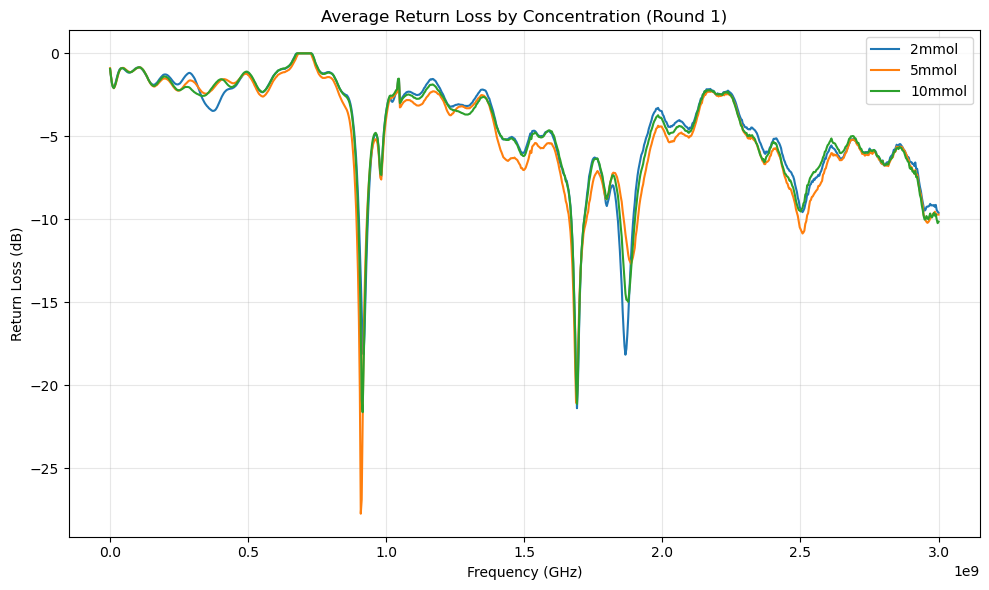

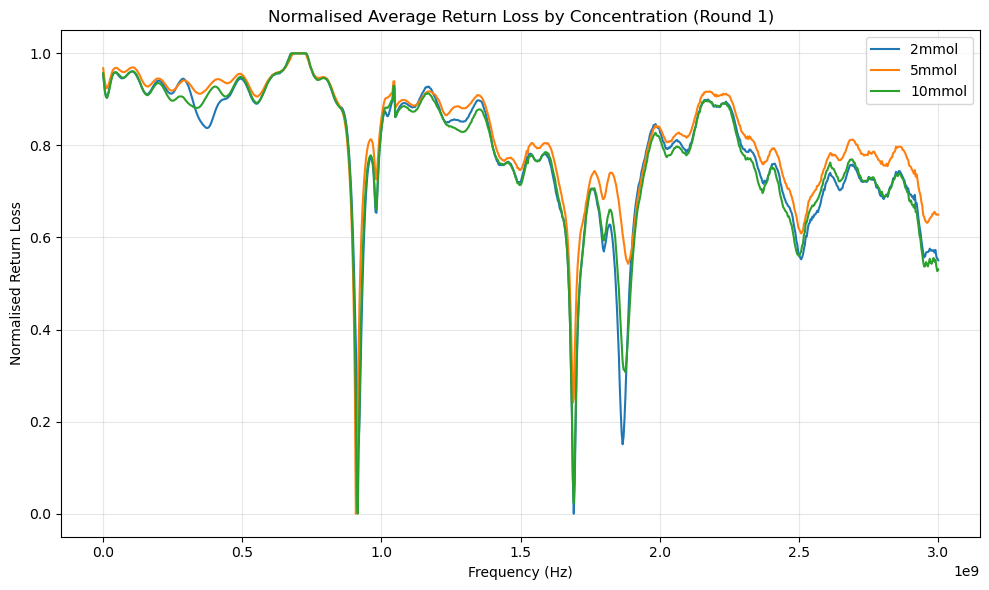


2mmol (normalised, averaged across 3 phantoms)
mean     : 0.789723
std      : 0.153178
min      : 0.000000
variance : 0.023464
skewness : -1.560220

5mmol (normalised, averaged across 3 phantoms)
mean     : 0.824090
std      : 0.124520
min      : 0.000000
variance : 0.015505
skewness : -1.648153

10mmol (normalised, averaged across 3 phantoms)
mean     : 0.788508
std      : 0.150197
min      : 0.000000
variance : 0.022559
skewness : -1.508485


In [35]:
# Group datasets by concentration
concentrations = {
    '2mmol':  [datasets['2mmol phantom 1'],  datasets['2mmol phantom 2'],  datasets['2mmol phantom 3']],
    '5mmol':  [datasets['5mmol phantom 1'],  datasets['5mmol phantom 2'],  datasets['5mmol phantom 3']],
    '10mmol': [datasets['10mmol phantom 1'], datasets['10mmol phantom 2'], datasets['10mmol phantom 3']],
}

col = 'Return Loss(dB)'
freq_col = 'Frequency(Hz)'

# Compute per-concentration averages
averaged = {}
frequencies = {}
for conc, dfs in concentrations.items():
    combined = pd.concat([df[col].reset_index(drop=True) for df in dfs], axis=1)
    averaged[conc] = combined.mean(axis=1)
    frequencies[conc] = dfs[0][freq_col].reset_index(drop=True)  # same across phantoms

# Print stats for each concentration
stats_col = 'Return Loss(dB)'

for conc, avg_series in averaged.items():
    print(f"\n{'='*50}")
    print(f"{conc} (averaged across 3 phantoms)")
    print(f"{'='*50}")
    print(f"mean     : {avg_series.mean():.6f}")
    print(f"std      : {avg_series.std():.6f}")
    print(f"min      : {avg_series.min():.6f}")
    print(f"variance : {avg_series.var():.6f}")
    print(f"skewness : {avg_series.skew():.6f}")


# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for conc, avg_series in averaged.items():
    ax.plot(frequencies[conc], avg_series.values, label=conc)

ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Return Loss (dB)')
ax.set_title(f'Average Return Loss by Concentration (Round {round})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Normalise each averaged series to [0, 1]
scaler = MinMaxScaler()

normalised = {}
for conc, avg_series in averaged.items():
    normalised[conc] = pd.Series(
        scaler.fit_transform(avg_series.values.reshape(-1, 1)).flatten(),
        index=avg_series.index
    )

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for conc, norm_series in normalised.items():
    ax.plot(frequencies[conc], norm_series.values, label=conc)

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Normalised Return Loss')
ax.set_title(f'Normalised Average Return Loss by Concentration (Round {round})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print stats on normalised data
for conc, norm_series in normalised.items():
    print(f"\n{'='*50}")
    print(f"{conc} (normalised, averaged across 3 phantoms)")
    print(f"{'='*50}")
    print(f"mean     : {norm_series.mean():.6f}")
    print(f"std      : {norm_series.std():.6f}")
    print(f"min      : {norm_series.min():.6f}")
    print(f"variance : {norm_series.var():.6f}")
    print(f"skewness : {norm_series.skew():.6f}")


2mmol (averaged across 3 phantoms)
mean     : 5.109367
std      : 108.326717
min      : -178.560000
variance : 11734.677642
skewness : -0.091316

5mmol (averaged across 3 phantoms)
mean     : 9.603963
std      : 107.653952
min      : -179.346667
variance : 11589.373359
skewness : -0.135489

10mmol (averaged across 3 phantoms)
mean     : 8.939120
std      : 107.516100
min      : -179.453333
variance : 11559.711813
skewness : -0.127166


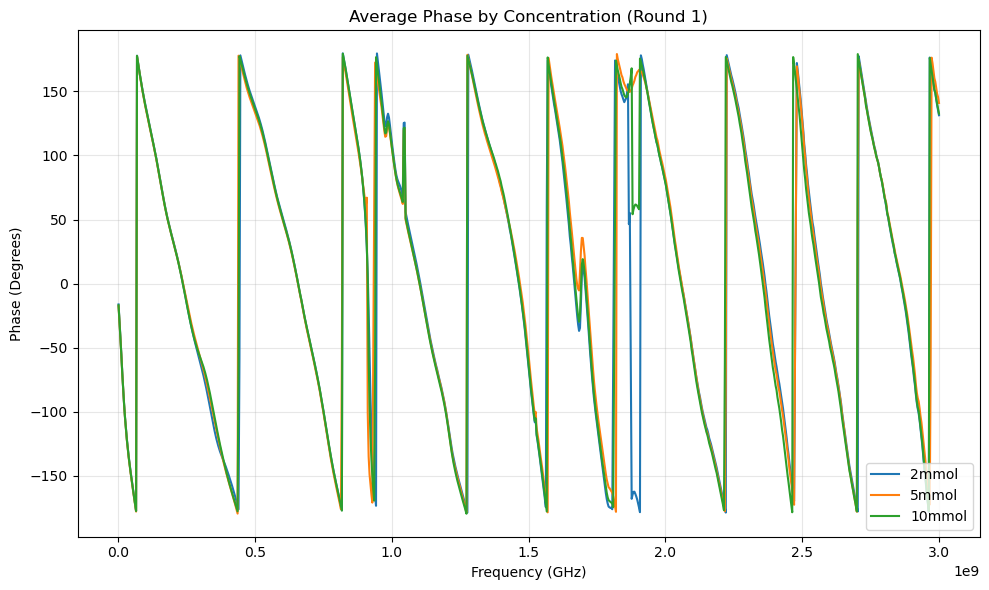

In [28]:
# Group datasets by concentration
concentrations = {
    '2mmol':  [datasets['2mmol phantom 1'],  datasets['2mmol phantom 2'],  datasets['2mmol phantom 3']],
    '5mmol':  [datasets['5mmol phantom 1'],  datasets['5mmol phantom 2'],  datasets['5mmol phantom 3']],
    '10mmol': [datasets['10mmol phantom 1'], datasets['10mmol phantom 2'], datasets['10mmol phantom 3']],
}

col = 'Phase(deg)'
freq_col = 'Frequency(Hz)'

# Compute per-concentration averages
averaged = {}
frequencies = {}
for conc, dfs in concentrations.items():
    combined = pd.concat([df[col].reset_index(drop=True) for df in dfs], axis=1)
    averaged[conc] = combined.mean(axis=1)
    frequencies[conc] = dfs[0][freq_col].reset_index(drop=True)  # same across phantoms


for conc, avg_series in averaged.items():
    print(f"\n{'='*50}")
    print(f"{conc} (averaged across 3 phantoms)")
    print(f"{'='*50}")
    print(f"mean     : {avg_series.mean():.6f}")
    print(f"std      : {avg_series.std():.6f}")
    print(f"min      : {avg_series.min():.6f}")
    print(f"variance : {avg_series.var():.6f}")
    print(f"skewness : {avg_series.skew():.6f}")


# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for conc, avg_series in averaged.items():
    ax.plot(frequencies[conc], avg_series.values, label=conc)

ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Phase (Degrees)')
ax.set_title(f'Average Phase by Concentration (Round {round})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 17 june
datasets = {
    '1 mmol phantom': min_conc,
    '10 mmol phantom': max_conc,
    'air': air,
    'None phantom': none_conc
}

cols = ['Return Loss(dB)']

for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")

    for col in cols:
        print(f"\n{col}")
        print(f"count    : {df[col].count()}")
        print(f"mean     : {df[col].mean()}")
        print(f"std      : {df[col].std()}")
        print(f"min      : {df[col].min()}")
        print(f"25%      : {df[col].quantile(0.25)}")
        print(f"median   : {df[col].median()}")
        print(f"75%      : {df[col].quantile(0.75)}")
        print(f"max      : {df[col].max()}")
        print(f"variance : {df[col].var()}")
        print(f"skewness : {df[col].skew()}")


1 mmol phantom

Return Loss(dB)
count    : 1003
mean     : -3.1150348953140576
std      : 2.9863847518373534
min      : -18.85
25%      : -3.2300000000000004
median   : -2.26
75%      : -1.4249999999999998
max      : 0.0
variance : 8.918493886006651
skewness : -2.339844742341841

10 mmol phantom

Return Loss(dB)
count    : 1003
mean     : -3.4361914257228316
std      : 3.6356215648662364
min      : -32.69
25%      : -3.475
median   : -2.47
75%      : -1.64
max      : 0.0
variance : 13.217744162920422
skewness : -3.7046162780321574

air

Return Loss(dB)
count    : 1003
mean     : -3.655752741774676
std      : 3.50461237384367
min      : -27.85
25%      : -4.955
median   : -3.26
75%      : -1.105
max      : 0.0
variance : 12.282307890898164
skewness : -2.4748318605359687

None phantom

Return Loss(dB)
count    : 1003
mean     : -3.5003688933200396
std      : 3.6988600719472724
min      : -34.91
25%      : -3.86
median   : -2.66
75%      : -1.71
max      : 0.0
variance : 13.6815658318457